In [1]:
!pip3 install -q --upgrade pip
!pip3 install -q pandas numpy matplotlib seaborn openpyxl climateserv requests netCDF4 xarray pyproj

In [2]:
import netCDF4 as nc
import numpy as np

def analyze_nasadem_file(file_path: str) -> None:
    """
    Analyze a NASADEM NetCDF file and print out its contents, such as variable names,
    dimensions, and min/max values for longitude and latitude.

    Args:
    file_path (str): The path to the NASADEM NetCDF file.
    """
    # Open the NetCDF file
    dataset = nc.Dataset(file_path, 'r')

    # Print general information about the file
    print('')
    print(f"Analyzing file: {file_path}")
    print("Variables in this file:")
    for var in dataset.variables:
        print(f" - {var}: {dataset.variables[var].dimensions}, {dataset.variables[var].shape}")

    # Check for common variables like longitude and latitude
    if 'lon' in dataset.variables and 'lat' in dataset.variables:
        lon = dataset.variables['lon'][:]
        lat = dataset.variables['lat'][:]
        print(f"Longitude range: {np.min(lon)} to {np.max(lon)}")
        print(f"Latitude range: {np.min(lat)} to {np.max(lat)}")
    
    # Close the dataset
    dataset.close()

# Paths to your files
file_paths = [
    'original_data/ndvi/MOD13Q1.061_250m_aid0001.nc',
]

# Analyze each file
for path in file_paths:
    analyze_nasadem_file(file_path=path)


Analyzing file: original_data/ndvi/MOD13Q1.061_250m_aid0001.nc
Variables in this file:
 - crs: (), ()
 - time: ('time',), (185,)
 - lat: ('lat',), (383,)
 - lon: ('lon',), (1589,)
 - _250m_16_days_EVI: ('time', 'lat', 'lon'), (185, 383, 1589)
 - _250m_16_days_MIR_reflectance: ('time', 'lat', 'lon'), (185, 383, 1589)
 - _250m_16_days_NDVI: ('time', 'lat', 'lon'), (185, 383, 1589)
 - _250m_16_days_VI_Quality: ('time', 'lat', 'lon'), (185, 383, 1589)
 - _250m_16_days_composite_day_of_the_year: ('time', 'lat', 'lon'), (185, 383, 1589)
 - _250m_16_days_pixel_reliability: ('time', 'lat', 'lon'), (185, 383, 1589)
Longitude range: -17.078124998470052 to -13.769791665433097
Latitude range: 13.078124998828393 to 13.873958332090432


In [3]:
import netCDF4 as nc
import numpy as np
import pandas as pd

def nasadem_to_dataframe(file_path: str) -> pd.DataFrame:
    """
    Convert a NASADEM NetCDF file to a Pandas DataFrame.

    Args:
    file_path (str): The path to the NASADEM NetCDF file.

    Returns:
    pd.DataFrame: A DataFrame containing the extracted data.
    """
    with nc.Dataset(file_path, 'r') as dataset:
        # Extract longitude and latitude arrays
        lon = dataset.variables['lon'][:]
        lat = dataset.variables['lat'][:]

        # Create a meshgrid for lon and lat
        lon_grid, lat_grid = np.meshgrid(lon, lat)

        # Flatten the lon and lat grids
        lon_flat = lon_grid.flatten()
        lat_flat = lat_grid.flatten()

        # Initialize a dictionary to hold data
        data = {'Longitude': lon_flat, 'Latitude': lat_flat}

        # Add other variables to the dictionary
        for var in ['_250m_16_days_NDVI', '_250m_16_days_EVI']:
            if var in dataset.variables:
                # Flatten and add to the data dictionary
                data[var] = dataset.variables[var][0, :, :].flatten()

        # Create a DataFrame from the dictionary
        df = pd.DataFrame(data)

    return df

# Paths to your files
file_paths = [
    'original_data/ndvi/MOD13Q1.061_250m_aid0001.nc',
]

# Convert each file to a DataFrame and analyze
for path in file_paths:
    df = nasadem_to_dataframe(file_path=path)
    print(df.head())  # Display the first few rows of the DataFrame


   Longitude   Latitude  _250m_16_days_NDVI  _250m_16_days_EVI
0 -17.078125  13.873958                 NaN                NaN
1 -17.076042  13.873958                 NaN                NaN
2 -17.073958  13.873958                 NaN                NaN
3 -17.071875  13.873958                 NaN                NaN
4 -17.069792  13.873958                 NaN                NaN


In [5]:
import netCDF4 as nc
import numpy as np
import pandas as pd

def nasadem_to_dataframe(file_path: str) -> pd.DataFrame:
    """
    Convert a NASADEM NetCDF file to a Pandas DataFrame, including the time variable.

    Args:
    file_path (str): The path to the NASADEM NetCDF file.

    Returns:
    pd.DataFrame: A DataFrame containing the extracted data.
    """
    with nc.Dataset(file_path, 'r') as dataset:
        # Extract longitude, latitude, and time arrays
        lon = dataset.variables['lon'][:]
        lat = dataset.variables['lat'][:]
        time = dataset.variables['time'][:]

        # Convert numeric time values to human-readable dates
        time_units = dataset.variables['time'].units
        time_calendar = dataset.variables['time'].calendar
        dates = nc.num2date(time, units=time_units, calendar=time_calendar)

        # Create a meshgrid for lon, lat, and time
        lon_grid, lat_grid, time_grid = np.meshgrid(lon, lat, dates, indexing='ij')

        # Flatten the grids
        lon_flat = lon_grid.flatten()
        lat_flat = lat_grid.flatten()
        time_flat = time_grid.flatten()

        # Initialize a dictionary to hold data
        data = {'Time': time_flat, 'Longitude': lon_flat, 'Latitude': lat_flat}

        # Add other variables to the dictionary
        for var in ['_250m_16_days_NDVI', '_250m_16_days_EVI']:
            if var in dataset.variables:
                # Extract, reshape to match time grid, and flatten
                var_data = dataset.variables[var][:]  # Includes the time dimension
                var_data_reshaped = var_data.reshape(var_data.shape[0], -1)  # Reshape for each time slice
                data[var] = var_data_reshaped.flatten()

        # Create a DataFrame from the dictionary
        df = pd.DataFrame(data)

    return df

def remove_nan_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove rows with NaN values in specific columns from the DataFrame.

    Args:
    df (pd.DataFrame): The original DataFrame.

    Returns:
    pd.DataFrame: A DataFrame with rows containing NaN values in specific columns removed.
    """
    return df.dropna(subset=['_250m_16_days_NDVI', '_250m_16_days_EVI'])

# Paths to your files
file_paths = [
    'original_data/ndvi/MOD13Q1.061_250m_aid0001.nc',
]

# Convert each file to a DataFrame, remove NaN rows, and analyze
for path in file_paths:
    df = nasadem_to_dataframe(file_path=path)
    df_no_nan = remove_nan_rows(df=df)
    df_no_nan  # Display the first few rows of the DataFrame

                  Time  Longitude   Latitude  _250m_16_days_NDVI  \
0  2014-12-19 00:00:00 -17.078125  13.873958                 NaN   
1  2015-01-01 00:00:00 -17.078125  13.873958                 NaN   
2  2015-01-17 00:00:00 -17.078125  13.873958                 NaN   
3  2015-02-02 00:00:00 -17.078125  13.873958                 NaN   
4  2015-02-18 00:00:00 -17.078125  13.873958                 NaN   

   _250m_16_days_EVI  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  


In [6]:
df

,Time,Longitude,Latitude,_250m_16_days_NDVI,_250m_16_days_EVI
0,2014-12-19 00:00:00,-17.078125,13.873958,NaN,NaN
1,2015-01-01 00:00:00,-17.078125,13.873958,NaN,NaN
2,2015-01-17 00:00:00,-17.078125,13.873958,NaN,NaN
3,2015-02-02 00:00:00,-17.078125,13.873958,NaN,NaN
4,2015-02-18 00:00:00,-17.078125,13.873958,NaN,NaN
...,...,...,...,...,...
112588590,2022-10-16 00:00:00,-13.769792,13.078125,0.5130,0.2398
112588591,2022-11-01 00:00:00,-13.769792,13.078125,0.5775,0.2711
112588592,2022-11-17 00:00:00,-13.769792,13.078125,0.5775,0.2711
112588593,2022-12-03 00:00:00,-13.769792,13.078125,0.5792,0.2673


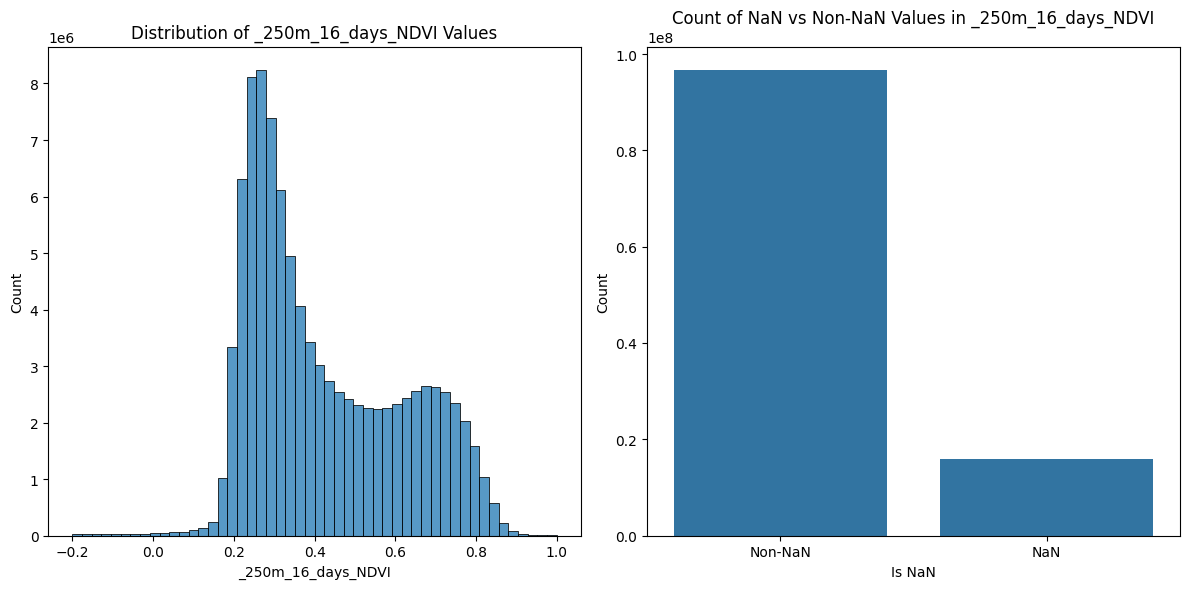

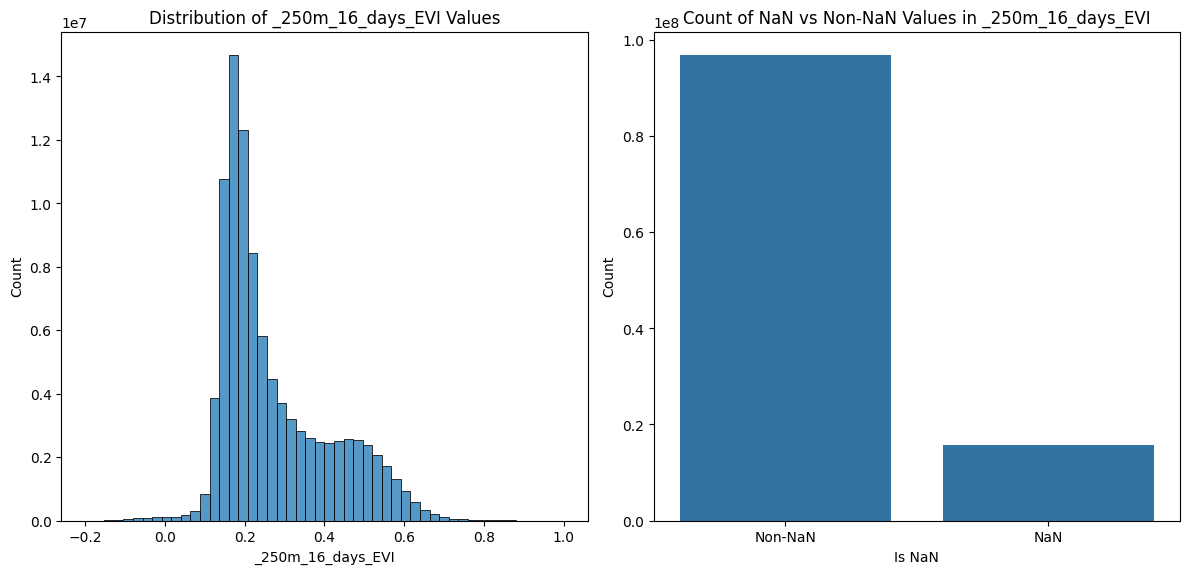

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_variable_distribution(df: pd.DataFrame, column_name: str) -> None:
    """
    Plots the distribution of values and NaN vs non-NaN counts for a specified column in the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        column_name (str): The name of the column to plot.
    """
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 6))

    # Histogram of values excluding NaNs
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name].dropna(), kde=False, bins=50)
    plt.title(f'Distribution of {column_name} Values')
    plt.xlabel(column_name)
    plt.ylabel('Count')

    # Count plot of NaN vs non-NaN values
    plt.subplot(1, 2, 2)
    nan_counts = df[column_name].isna().value_counts()
    sns.barplot(x=nan_counts.index, y=nan_counts.values)
    plt.title(f'Count of NaN vs Non-NaN Values in {column_name}')
    plt.xlabel('Is NaN')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Non-NaN', 'NaN'])

    plt.tight_layout()
    plt.show()

# Call the function for each column
plot_variable_distribution(df=df, column_name='_250m_16_days_NDVI')
plot_variable_distribution(df=df, column_name='_250m_16_days_EVI')
